# **Pipeline: Original Graph G → Generate Node Features X → Construct Graph Pair (Gs, Gt) + Ground Truth → Add Noise (Structural + Attributive) → Convert to Matrix Form (A, X) → Embedding / Representation Learning → Compute Similarity Matrix → Matching (Alignment) → Evaluation (Accuracy / Hit@k)**

## **1. Environment Setup**

In [1]:
!pip install "numpy<2" node2vec
!pip install scikit-learn scipy pandas matplotlib torch networkx

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   --- ------------------------------------ 1.6/15.8 MB 8.4 MB/s eta 0:00:02
   --------- ------------------------------ 3.9/15.8 MB 9.4 MB/s eta 0:00:02
   --------------- ------------------------ 6.0/15.8 MB 9.7 MB/s eta 0:00:02
   ------------------- -------------------- 7.9/15.8 MB 9.7 MB/s eta 0:00:01
   ------------------------ --------------- 9.7/15.8 MB 9.4 MB/s eta 0:00:01
   ----------------------------- ---------- 11.8/15.8 MB 9.7 MB/s eta 0:00:01
   ----------------------------------- ---- 14.2/15.8 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 9.9 MB/s  0:00:01
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   --- ------------------------------------ 2.1/24.4 MB

## **2. Path Configuration and Import**

In [2]:
import os
import sys
sys.path.append(os.path.abspath("src"))

from data_utils import *
from noise_utils import *
from matching import *
from metrics import *
from baselines import *
from models import *
from experiment import *

C:\Users\23293\anaconda3\envs\netalign\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **3. Parameter Configuration**


In [3]:
SEED = 42
DEBUG = True

EDGE_NOISE_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.5]
ATTR_NOISE_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.5]

EMBED_DIM = 64
NUM_RUNS = 3
TOPK = [1, 5]
USE_HUNGARIAN = True
DEVICE = "cuda"  # or "cpu"

DATASET_NAME = "karate"

## **4. Debugging a Single Run**

In [4]:
set_seed(SEED)

G, X = prepare_dataset(DATASET_NAME, feat_dim=16)
Gs, Gt, Xs, Xt, gt_map = generate_permuted_graph_pair(G, X)
Gs_n, Gt_n, Xs_n, Xt_n = build_noisy_pair(Gs, Gt, Xs, Xt, edge_noise=0.1, attr_noise=0.2)

As, src_nodes = graph_to_adjacency(Gs_n)
At, tgt_nodes = graph_to_adjacency(Gt_n)
gt_idx = build_gt_index_map(src_nodes, tgt_nodes, gt_map)

## **5. Run the baseline**

In [5]:
Zs, _ = node2vec_embed(Gs_n, dim=EMBED_DIM)
Zt, _ = node2vec_embed(Gt_n, dim=EMBED_DIM)
sim = similarity_matrix(Zs, Zt)
pred = match_nearest_neighbor(sim)

print("Node2Vec Accuracy:", accuracy_at_1(pred, gt_idx))
print("Node2Vec Hit@1:", hit_at_k(sim, gt_idx, 1))
print("Node2Vec Hit@5:", hit_at_k(sim, gt_idx, 5))

Generating walks (CPU: 1): 100%|██████████████████████████████████████████████████████| 50/50 [00:00<00:00, 613.82it/s]

Node2Vec Accuracy: 0.23529411764705882
Node2Vec Hit@1: 0.23529411764705882
Node2Vec Hit@5: 0.5294117647058824


### **Final Run:**

In [6]:
final = FINALAligner(alpha=0.8, max_iter=30).fit(As, At, Xs_n, Xt_n)
S = final.predict_score_matrix()
pred_final = final.predict_top1(use_hungarian=False)

print("FINAL Accuracy:", accuracy_at_1(pred_final, gt_idx))
print("FINAL Hit@1:", hit_at_k(S, gt_idx, 1))
print("FINAL Hit@5:", hit_at_k(S, gt_idx, 5))

FINAL Accuracy: 0.058823529411764705
FINAL Hit@1: 0.058823529411764705
FINAL Hit@5: 0.17647058823529413


## **6. Running the Overall Experiment**

In [7]:
df = run_experiments(
    G, X,
    edge_noise_levels=EDGE_NOISE_LEVELS,
    attr_noise_levels=ATTR_NOISE_LEVELS,
    runs=NUM_RUNS,
    embed_dim=EMBED_DIM
)

df.head()

Generating walks (CPU: 1): 100%|██████████████████████████████████████████████████████| 50/50 [00:00<00:00, 682.11it/s]


,method,edge_noise,attr_noise,run,acc,hit1,hit5,runtime
0,Node2Vec+NN,0.0,0.0,0,0.117647,0.117647,0.617647,1.065052
1,FINAL-style,0.0,0.0,0,0.058824,0.058824,0.235294,NaN
2,Node2Vec+NN,0.0,0.0,1,0.088235,0.088235,0.441176,0.299001
3,FINAL-style,0.0,0.0,1,0.058824,0.058824,0.235294,NaN
4,Node2Vec+NN,0.0,0.0,2,0.088235,0.088235,0.441176,0.288858


## **7. Save Results**

In [8]:
df.to_csv("results/experiment_results.csv", index=False)

## **8. Drawing**

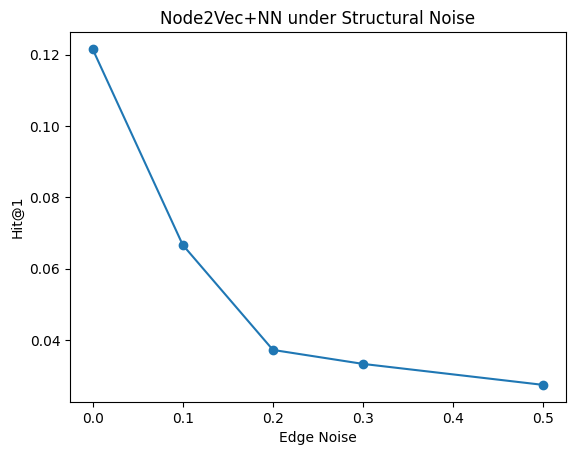

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

subset = df[df["method"] == "Node2Vec+NN"]
mean_df = subset.groupby("edge_noise")["hit1"].mean().reset_index()

plt.plot(mean_df["edge_noise"], mean_df["hit1"], marker="o")
plt.xlabel("Edge Noise")
plt.ylabel("Hit@1")
plt.title("Node2Vec+NN under Structural Noise")
plt.show()